<a href="https://colab.research.google.com/github/dulaksha-chathura/EN3160-Assignment-1-on-Intensity-Transformations-and-Neighborhood-Filtering/blob/main/230100M_a01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EN3160 Assignment 01 - Question 1
**Index Number:** 230100M
**Name:** Chandrakumara H.A.D.C.
**GitHub:** https://github.com/dulaksha-chathura/EN3160-Assignment-1-on-Intensity-Transformations-and-Neighborhood-Filtering

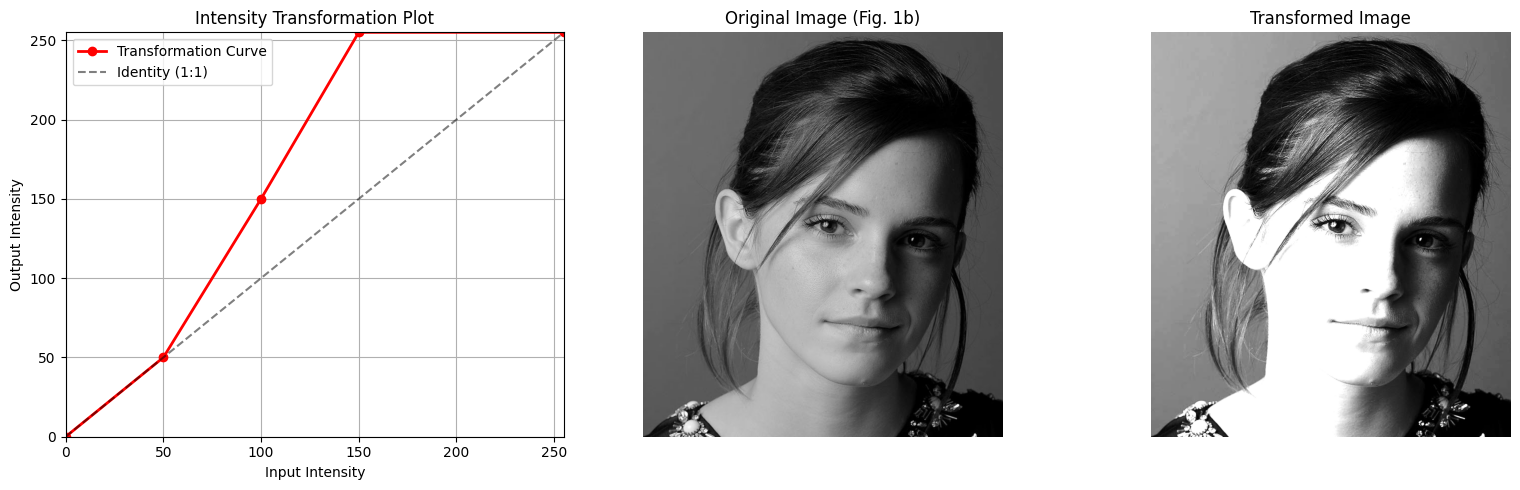

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# 1. Function Definition for Piecewise Linear Intensity Transformation
# ---------------------------------------------------------


def intensity_transform(im, breakpoints):
    """Applies piecewise linear intensity transformation based on given breakpoints.

    breakpoints: Nx2 list/array of [input_intensity, output_intensity] pairs.
    """
    # Ensure breakpoints are sorted by input intensity (x-axis)
    breakpoints = np.array(sorted(breakpoints, key=lambda x: x[0]))

    xp = breakpoints[:, 0]  # Input intensity coordinates
    fp = breakpoints[:, 1]  # Output intensity coordinates

    # Compute lookup table (LUT) using linear interpolation across [0, 255]
    lut = np.interp(np.arange(256), xp, fp).astype(np.uint8)

    # Apply lookup table transformation to image
    transformed_im = cv2.LUT(im, lut)

    return transformed_im, xp, fp


# ---------------------------------------------------------
# 2. Load the Input Image
# ---------------------------------------------------------
# Replace 'q1.jpeg' with the exact filename you uploaded to Colab
image_path = "q1.jpeg"

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Sanity check to confirm image is loaded properly
if img is None:
    print(
        f"Error: Could not find '{image_path}'. Please upload it to Colab's file sidebar."
    )
else:
    # ---------------------------------------------------------
    # 3. Define Breakpoints (Given in Q1 specification)
    # ---------------------------------------------------------
    breakpoints = [[0, 0], [50, 50], [100, 150], [150, 255], [255, 255]]

    # Apply transformation
    transformed_img, x_pts, y_pts = intensity_transform(img, breakpoints)

    # ---------------------------------------------------------
    # 4. Display Results (Transformation Plot + Side-by-Side Images)
    # ---------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Plot 1: Intensity Transformation Plot
    axes[0].plot(x_pts, y_pts, "r-o", linewidth=2, label="Transformation Curve")
    axes[0].plot([0, 255], [0, 255], "k--", alpha=0.5, label="Identity (1:1)")
    axes[0].set_title("Intensity Transformation Plot")
    axes[0].set_xlabel("Input Intensity")
    axes[0].set_ylabel("Output Intensity")
    axes[0].set_xlim([0, 255])
    axes[0].set_ylim([0, 255])
    axes[0].grid(True)
    axes[0].legend()

    # Plot 2: Original Image
    axes[1].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[1].set_title("Original Image (Fig. 1b)")
    axes[1].axis("off")

    # Plot 3: Transformed Image
    axes[2].imshow(transformed_img, cmap="gray", vmin=0, vmax=255)
    axes[2].set_title("Transformed Image")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

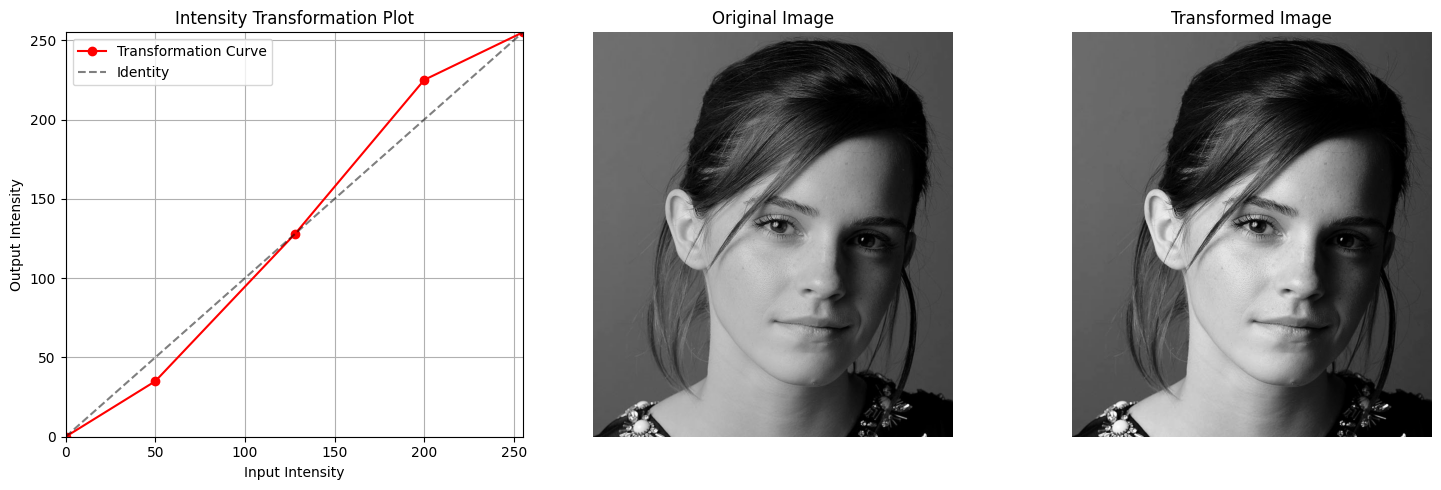

In [4]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


def intensity_transform(im, breakpoints):
    bp = np.array(sorted(breakpoints, key=lambda x: x[0]))
    lut = np.interp(np.arange(256), bp[:, 0], bp[:, 1]).astype(np.uint8)
    return cv2.LUT(im, lut), bp[:, 0], bp[:, 1]


img = cv2.imread("q1.jpeg", cv2.IMREAD_GRAYSCALE)
breakpoints = [[0, 0], [50, 35], [128, 128], [200, 225], [255, 255]]

transformed_img, x_pts, y_pts = intensity_transform(img, breakpoints)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(x_pts, y_pts, "r-o", label="Transformation Curve")
axes[0].plot([0, 255], [0, 255], "k--", alpha=0.5, label="Identity")
axes[0].set_title("Intensity Transformation Plot")
axes[0].set_xlabel("Input Intensity")
axes[0].set_ylabel("Output Intensity")
axes[0].set_xlim([0, 255])
axes[0].set_ylim([0, 255])
axes[0].grid(True)
axes[0].legend()

axes[1].imshow(img, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Original Image")
axes[1].axis("off")

axes[2].imshow(transformed_img, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("Transformed Image")
axes[2].axis("off")

plt.tight_layout()
plt.show()